In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    sys.path.insert(0, '..')

# 03 — Baseline Model
Evaluate unregularized logistic regression across all pipeline × dataset combinations. Primary metric: PR-AUC.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from src.data_loader import get_all_datasets
from src.preprocessing import get_pipelines
from src.models import make_baseline
from src.evaluation import cross_val_evaluate, summarize_cv_results, save_table
from src.utils import RANDOM_STATE, Timer

datasets = get_all_datasets()
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

holdout = {}
for name, (X, y) in datasets.items():
    X_main, X_test, y_main, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    holdout[name] = (X_main, y_main, X_test, y_test)

2026-05-15 18:51:17,275 — Bonn dataset files not found. Using synthetic fallback (500, 4097).
2026-05-15 18:51:17,275 — Generating synthetic Bonn-like data for development...


In [3]:
# Run baseline CV across all pipeline × dataset combos
baseline_results = {}
rows = []

for dataset_name, (X, y, _, _) in holdout.items():
    pipelines = get_pipelines(dataset_name)
    for pipe_name, pipe in pipelines.items():
        with Timer() as t:
            results = cross_val_evaluate(pipe, make_baseline(), X, y, CV)
        summary = summarize_cv_results(results)
        baseline_results[(pipe_name, dataset_name)] = results
        rows.append({
            'Pipeline': pipe_name,
            'Dataset': dataset_name,
            'PR-AUC': f"{summary['pr_auc']['mean']:.3f} ± {summary['pr_auc']['std']:.3f}",
            'F1': f"{summary['f1']['mean']:.3f} ± {summary['f1']['std']:.3f}",
            'Recall': f"{summary['recall']['mean']:.3f} ± {summary['recall']['std']:.3f}",
            'CI 95% PR-AUC': f"[{summary['pr_auc']['ci_low']:.3f}, {summary['pr_auc']['ci_high']:.3f}]",
            'Time (s)': f'{t.elapsed:.1f}',
        })

table1 = pd.DataFrame(rows)
print(table1.to_string(index=False))
save_table(table1, 'table1_pipeline_dataset')

c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penal

Pipeline       Dataset        PR-AUC            F1        Recall  CI 95% PR-AUC Time (s)
       A   uci_seizure 0.475 ± 0.029 0.059 ± 0.023 0.030 ± 0.012 [0.435, 0.515]     23.0
       B   uci_seizure 0.480 ± 0.011 0.105 ± 0.013 0.055 ± 0.007 [0.465, 0.495]      0.4
       A      bonn_eeg 0.452 ± 0.044 0.270 ± 0.052 0.212 ± 0.050 [0.391, 0.512]     42.0
       B      bonn_eeg 0.416 ± 0.040 0.371 ± 0.029 0.369 ± 0.036 [0.360, 0.471]      2.0
       C      bonn_eeg 0.404 ± 0.043 0.125 ± 0.070 0.075 ± 0.042 [0.345, 0.464]      3.5
       A eeg_eye_state 0.618 ± 0.007 0.546 ± 0.014 0.488 ± 0.020 [0.608, 0.627]      2.5
       B eeg_eye_state 0.559 ± 0.009 0.370 ± 0.015 0.287 ± 0.017 [0.546, 0.572]      0.2


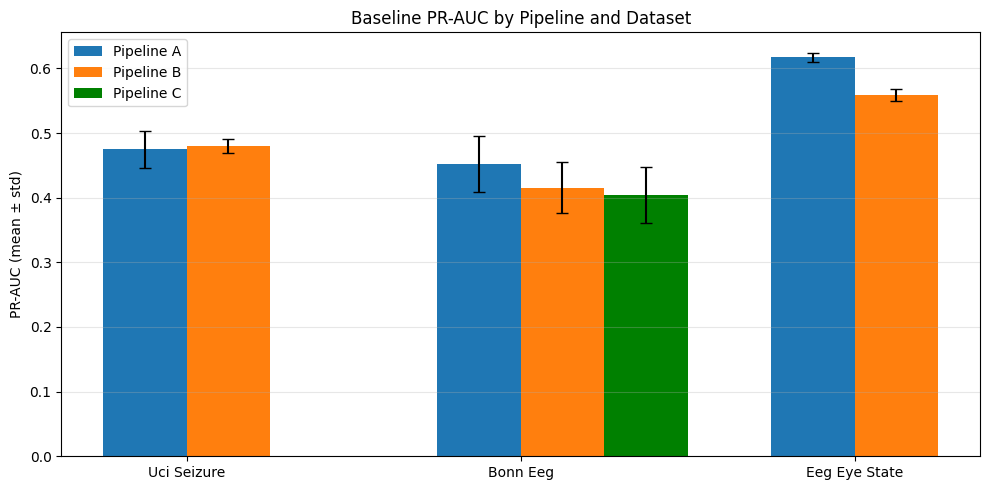

In [4]:
# Bar chart: PR-AUC per pipeline per dataset
import matplotlib.pyplot as plt

dataset_names = list(datasets.keys())
pipeline_names = ['A', 'B']
x = np.arange(len(dataset_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, pipe_name in enumerate(pipeline_names):
    means = []
    stds = []
    for ds in dataset_names:
        key = (pipe_name, ds)
        if key in baseline_results:
            means.append(baseline_results[key]['pr_auc'].mean())
            stds.append(baseline_results[key]['pr_auc'].std())
        else:
            means.append(0); stds.append(0)
    ax.bar(x + i * width, means, width, yerr=stds, label=f'Pipeline {pipe_name}', capsize=4)

# Add Pipeline C for bonn_eeg if available
bonn_idx = dataset_names.index('bonn_eeg')
if ('C', 'bonn_eeg') in baseline_results:
    c_mean = baseline_results[('C', 'bonn_eeg')]['pr_auc'].mean()
    c_std = baseline_results[('C', 'bonn_eeg')]['pr_auc'].std()
    ax.bar(x[bonn_idx] + 2 * width, c_mean, width, yerr=c_std, label='Pipeline C', capsize=4, color='green')

ax.set_xticks(x + width / 2)
ax.set_xticklabels([d.replace('_', ' ').title() for d in dataset_names])
ax.set_ylabel('PR-AUC (mean ± std)')
ax.set_title('Baseline PR-AUC by Pipeline and Dataset')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/baseline_pr_auc.png', dpi=150)
plt.show()